# Projeto de Análise de Dados de E-commerce

## Objetivo
Analisar dados de vendas utilizando SQL e Python.

## Importação das Bibliotecas

In [10]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


## Carregamento dos Dados

In [11]:
# Carregando os dados dos arquivos CSV
orders = pd.read_csv("../data/olist_orders_dataset.csv")

items = pd.read_csv("../data/olist_order_items_dataset.csv")

customers = pd.read_csv("../data/olist_customers_dataset.csv")

products = pd.read_csv("../data/olist_products_dataset.csv")

reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")

geo = pd.read_csv("../data/olist_geolocation_dataset.csv")

## Exploração Inicial dos Dados

In [12]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [15]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [16]:
orders.shape

(99441, 8)

In [17]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [18]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


## Criação do Banco SQL

In [19]:
# Criando uma conexão com o banco de dados SQLite
conn = sqlite3.connect("../data/ecommerce.db")

In [20]:
# Salvando os DataFrames no banco de dados SQLite
orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

99441

In [21]:
items.to_sql(
    "items",
    conn,
    if_exists="replace",
    index=False
)

112650

In [22]:
customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

99441

In [23]:
products.to_sql(
    "products",
    conn,
    if_exists="replace",
    index=False
)

32951

In [24]:
reviews.to_sql(
    "reviews", 
    conn, 
    if_exists="replace", 
    index=False)

99224

## Consultas SQL

### Total de Pedidos

In [25]:
query = """
SELECT 
    COUNT(*) AS total_pedidos
FROM orders
"""

pd.read_sql(query, conn)

,total_pedidos
0,99441


### Faturamento Total

In [26]:
query = """
SELECT
    ROUND(SUM(price), 2) AS faturamento_total
FROM items
"""

pd.read_sql(query, conn)

,faturamento_total
0,13591643.7


### Categorias de Produtos mais vendidos

In [27]:
query = """
SELECT
    products.product_category_name AS categoria,
    COUNT(*) AS total_vendas

FROM items

JOIN products
ON items.product_id = products.product_id

GROUP BY products.product_category_name

ORDER BY total_vendas DESC

LIMIT 10
"""

top_categorias = pd.read_sql(query, conn)

top_categorias

,categoria,total_vendas
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641
3,moveis_decoracao,8334
4,informatica_acessorios,7827
5,utilidades_domesticas,6964
6,relogios_presentes,5991
7,telefonia,4545
8,ferramentas_jardim,4347
9,automotivo,4235


### Faturamento por Categoria

In [28]:
query = """
SELECT
    products.product_category_name AS categoria,
    ROUND(SUM(items.price),2) AS faturamento

FROM items

JOIN products
ON items.product_id = products.product_id

GROUP BY products.product_category_name

ORDER BY faturamento DESC

LIMIT 10
"""

faturamento_categoria = pd.read_sql(query, conn)

faturamento_categoria

,categoria,faturamento
0,beleza_saude,1258681.34
1,relogios_presentes,1205005.68
2,cama_mesa_banho,1036988.68
3,esporte_lazer,988048.97
4,informatica_acessorios,911954.32
5,moveis_decoracao,729762.49
6,cool_stuff,635290.85
7,utilidades_domesticas,632248.66
8,automotivo,592720.11
9,ferramentas_jardim,485256.46


### Distribuição dos Preços dos Produtos

In [29]:
query = """
SELECT
    price

FROM items
"""

precos = pd.read_sql(query, conn)

precos

,price
0,58.90
1,239.90
2,199.00
3,12.99
4,199.90
...,...
112645,299.99
112646,350.00
112647,99.90
112648,55.99


### Estados com mais vendas

In [30]:
query = """
SELECT
    customers.customer_state AS estado,
    COUNT(items.order_id) AS total_vendas

FROM customers

JOIN orders
ON customers.customer_id = orders.customer_id

JOIN items
ON orders.order_id = items.order_id

GROUP BY customers.customer_state

ORDER BY total_vendas DESC

LIMIT 10
"""

estados_vendas = pd.read_sql(query, conn)

estados_vendas

,estado,total_vendas
0,SP,47449
1,RJ,14579
2,MG,13129
3,RS,6235
4,PR,5740
5,SC,4176
6,BA,3799
7,DF,2406
8,GO,2333
9,ES,2256


In [31]:
query = """
SELECT
    ROUND(AVG(price),2) AS ticket_medio
FROM items
"""

pd.read_sql(query, conn)

,ticket_medio
0,120.65


### Ticket Médio Por Estado

In [32]:
query = """
SELECT
    customers.customer_state,
    ROUND(AVG(items.price),2) AS ticket_medio

FROM customers

JOIN orders
ON customers.customer_id = orders.customer_id

JOIN items
ON orders.order_id = items.order_id

GROUP BY customers.customer_state

ORDER BY ticket_medio DESC

LIMIT 10
"""

ticket_estado = pd.read_sql(query, conn)

ticket_estado

,customer_state,ticket_medio
0,PB,191.48
1,AL,180.89
2,AC,173.73
3,RO,165.97
4,PA,165.69
5,AP,164.32
6,PI,160.36
7,TO,157.53
8,RN,156.97
9,CE,153.76


### Análise Temporal

In [33]:
# Convertendo a coluna de data para o formato datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [34]:
query = """
SELECT
    substr(order_purchase_timestamp,1,7) AS mes,
    ROUND(SUM(items.price),2) AS faturamento

FROM orders

JOIN items
ON orders.order_id = items.order_id

GROUP BY mes

ORDER BY mes
"""

vendas_mes = pd.read_sql(query, conn)

vendas_mes

,mes,faturamento
0,2016-09,267.36
1,2016-10,49507.66
2,2016-12,10.90
3,2017-01,120312.87
4,2017-02,247303.02
5,2017-03,374344.30
6,2017-04,359927.23
7,2017-05,506071.14
8,2017-06,433038.60
9,2017-07,498031.48


### Categorias com alto faturamento mas avaliação baixa


In [35]:
query = """
SELECT
    p.product_category_name AS categoria,
    ROUND(SUM(i.price), 2) AS faturamento,
    ROUND(AVG(r.review_score), 2) AS nota_media,
    COUNT(*) AS total_vendas

FROM items i
JOIN products p ON i.product_id = p.product_id
JOIN orders o ON i.order_id = o.order_id
JOIN reviews r ON o.order_id = r.order_id

WHERE p.product_category_name IS NOT NULL

GROUP BY p.product_category_name

HAVING total_vendas > 100

ORDER BY faturamento DESC

LIMIT 15
"""

df_cat_review = pd.read_sql(query, conn)
df_cat_review

,categoria,faturamento,nota_media,total_vendas
0,beleza_saude,1252404.85,4.14,9645
1,relogios_presentes,1197565.48,4.02,5950
2,cama_mesa_banho,1040140.31,3.90,11137
3,esporte_lazer,986848.92,4.11,8640
4,informatica_acessorios,914579.39,3.93,7849
5,moveis_decoracao,729864.42,3.90,8331
6,utilidades_domesticas,630058.22,4.06,6943
7,cool_stuff,629561.68,4.15,3772
8,automotivo,586669.90,4.07,4213
9,ferramentas_jardim,482946.89,4.04,4329


### Pedidos por dia da semana e hora do dia

In [36]:
# Extraindo dia da semana e hora
orders["dia_semana"] = orders["order_purchase_timestamp"].dt.day_name()
orders["hora"] = orders["order_purchase_timestamp"].dt.hour

# Mapeando para português
dias_pt = {
    "Monday": "Segunda", "Tuesday": "Terça", "Wednesday": "Quarta",
    "Thursday": "Quinta", "Friday": "Sexta", "Saturday": "Sábado", "Sunday": "Domingo"
}
ordem_dias = ["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"]

orders["dia_semana_pt"] = orders["dia_semana"].map(dias_pt)

pedidos_dia = orders["dia_semana_pt"].value_counts().reindex(ordem_dias)
pedidos_hora = orders["hora"].value_counts().sort_index()

### Frete vs distância 

In [37]:
# Pegando uma coordenada por CEP (primeiro registro)
geo_unique = geo.groupby("geolocation_zip_code_prefix").first().reset_index()

# Juntando com clientes
customers["zip_prefix"] = customers["customer_zip_code_prefix"]

clientes_geo = customers.merge(
    geo_unique[["geolocation_zip_code_prefix", "geolocation_state"]],
    left_on="zip_prefix",
    right_on="geolocation_zip_code_prefix",
    how="left"
)

# Frete médio por estado
query_frete = """
SELECT
    c.customer_state AS estado,
    ROUND(AVG(i.freight_value), 2) AS frete_medio,
    ROUND(AVG(i.price), 2) AS ticket_medio,
    COUNT(*) AS total_pedidos

FROM items i
JOIN orders o ON i.order_id = o.order_id
JOIN customers c ON o.customer_id = c.customer_id

GROUP BY c.customer_state
HAVING total_pedidos > 50

ORDER BY frete_medio DESC
"""

df_frete = pd.read_sql(query_frete, conn)
df_frete

,estado,frete_medio,ticket_medio,total_pedidos
0,RR,42.98,150.57,52
1,PB,42.72,191.48,602
2,RO,41.07,165.97,278
3,AC,40.07,173.73,92
4,PI,39.15,160.36,542
5,MA,38.26,145.20,824
6,TO,37.25,157.53,315
7,SE,36.65,153.04,385
8,AL,35.84,180.89,444
9,PA,35.83,165.69,1080


## Visualização dos Dados

### Categorias com Mais Vendas

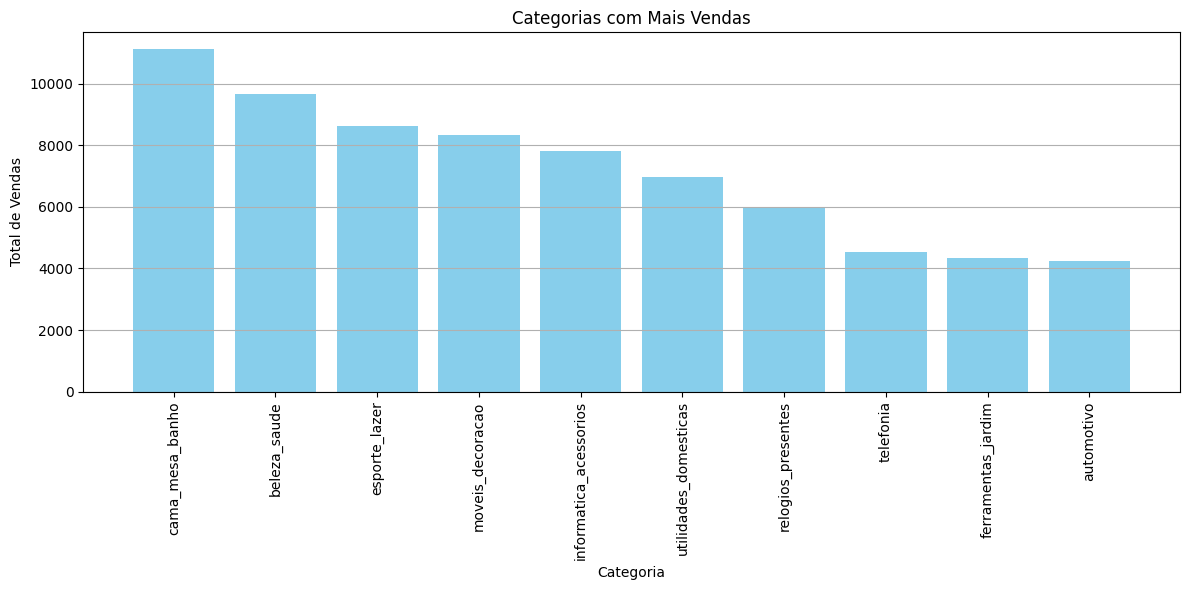

In [38]:
plt.figure(figsize=(12,6))


plt.bar(top_categorias["categoria"], top_categorias["total_vendas"], color="skyblue")

top_categorias["categoria"] = top_categorias[
    "categoria"
    ].str.replace("_", " & ")


plt.title("Categorias com Mais Vendas")

plt.xlabel("Categoria")

plt.ylabel("Total de Vendas")

plt.xticks(rotation=90)

plt.grid(axis="y")

plt.tight_layout()

plt.savefig("../images/categorias_vendas.png", dpi=300, bbox_inches="tight")

plt.show()

#### Insight - Categorias com Mais Vendas
Algumas categorias concentram grande parte das vendas da plataforma, mostrando que determinados segmentos possuem maior demanda entre os consumidores.

### Estados com Mais Vendas

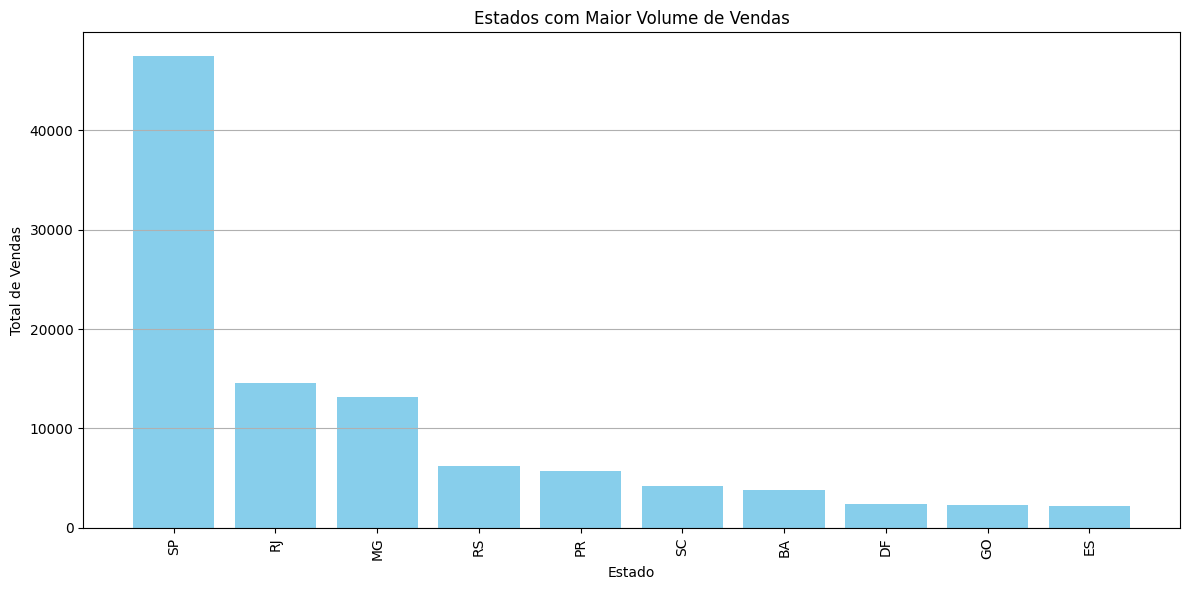

In [39]:
plt.figure(figsize=(12,6))


plt.bar(estados_vendas["estado"], estados_vendas["total_vendas"], color="skyblue")

plt.title("Estados com Maior Volume de Vendas")

plt.xlabel("Estado")

plt.ylabel("Total de Vendas")

plt.xticks(rotation=90)

plt.grid(axis="y")

plt.tight_layout()

plt.savefig("../images/estados_vendas.png", dpi=300, bbox_inches="tight")

plt.show()

#### Insight - Estados com mais vendas

O gráfico da demonstra a grande concentração de vendas na região sudeste, principalmente no Estado de São Paulo, que é o Estado com mais vendas com ligeira vanagem para os demais.

### Categorias com Maior Faturamento

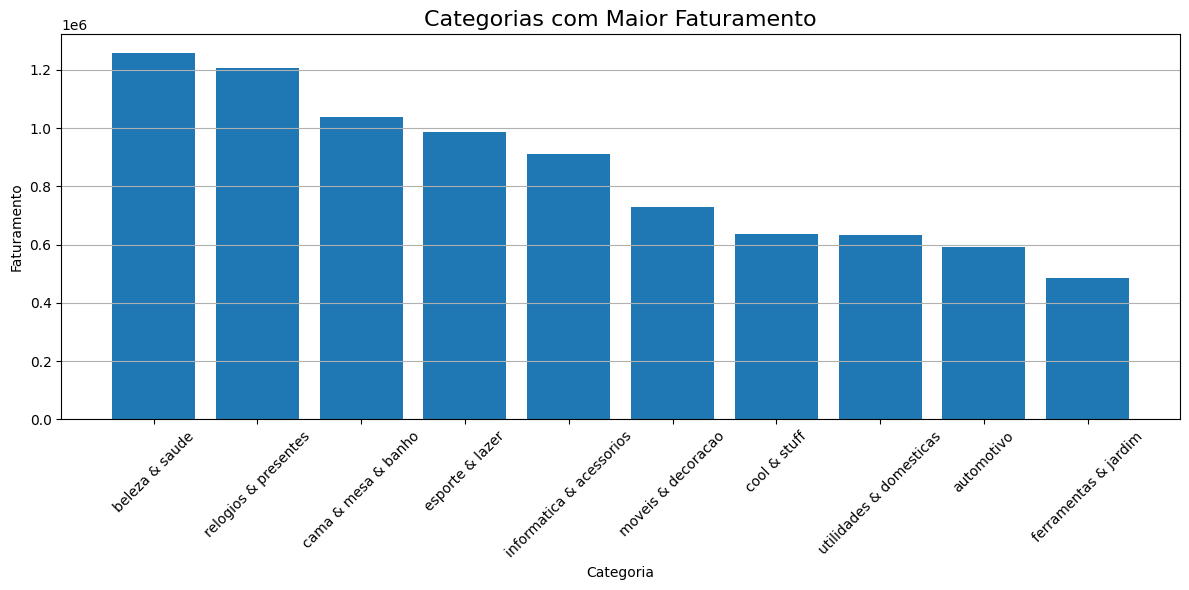

In [40]:
plt.figure(figsize=(12,6))

faturamento_categoria["categoria"] = faturamento_categoria[
    "categoria"
    ].str.replace("_", " & ")

plt.bar(
    faturamento_categoria["categoria"],
    faturamento_categoria["faturamento"]
)


plt.title(
    "Categorias com Maior Faturamento",
    fontsize=16
)

plt.xlabel("Categoria")

plt.ylabel("Faturamento")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.savefig("../images/categorias_faturamento.png", dpi=300, bbox_inches="tight")

plt.show()

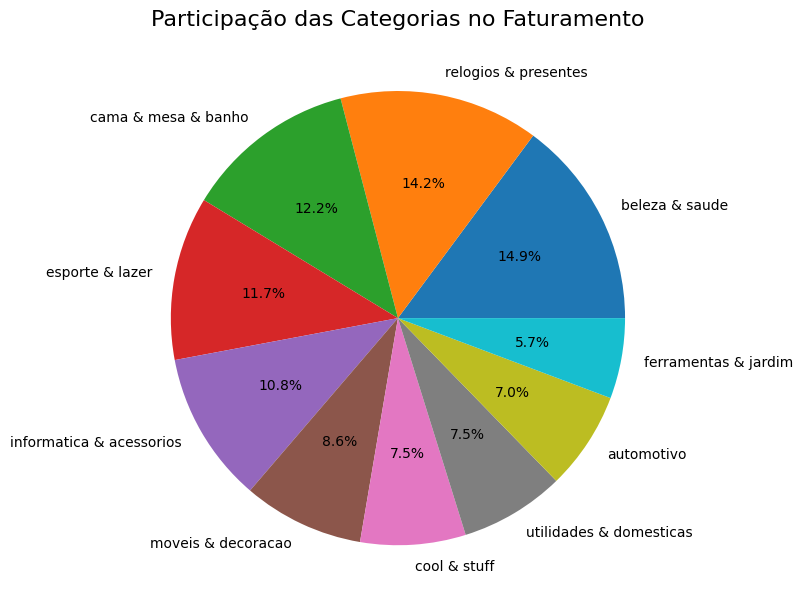

In [41]:
plt.figure(figsize=(8,8))

plt.pie(
    faturamento_categoria["faturamento"],
    labels=faturamento_categoria["categoria"],
    autopct="%1.1f%%"
)

plt.title(
    "Participação das Categorias no Faturamento",
    fontsize=16
)

plt.tight_layout()

plt.savefig("../images/categorias_faturamento_pizza.png", dpi=300, bbox_inches="tight")

plt.show()

#### Insight - Categorias Com Maior Faturamento

O faturamento da plataforma está relativamente concentrado em algumas categorias específicas, com destaque para Beleza & Saúde, Relógios & Presentes e Cama, Mesa & Banho. Juntas, essas categorias representam uma parcela significativa da receita total do e-commerce, indicando forte relevância desses segmentos para o desempenho financeiro da plataforma.

### Distribuição dos Preços dos Produtos

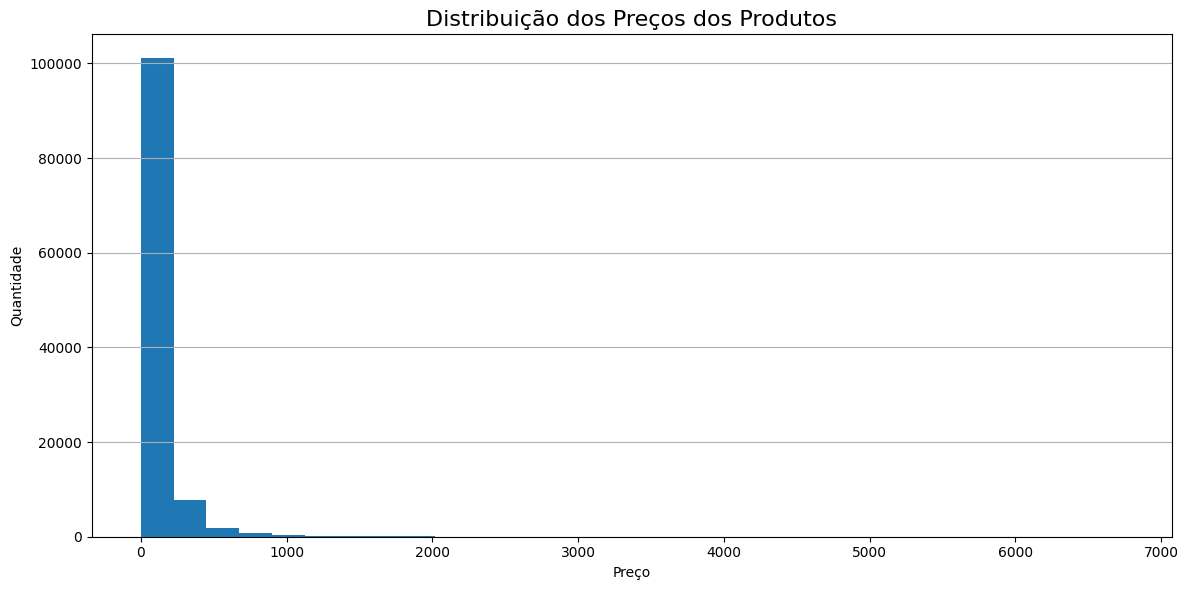

In [42]:
plt.figure(figsize=(12,6))

plt.hist(
    precos["price"],
    bins=30
)

plt.title(
    "Distribuição dos Preços dos Produtos",
    fontsize=16
)

plt.xlabel("Preço")

plt.ylabel("Quantidade")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig("../images/histograma_precos.png", dpi=300, bbox_inches="tight")

plt.show()

#### Insight

A maior parte dos produtos está concentrada em faixas de preço mais baixas, enquanto produtos de maior valor aparecem em menor quantidade. Esse comportamento indica predominância de itens de preço acessível no e-commerce.

### Estados com Maior Ticket Médio

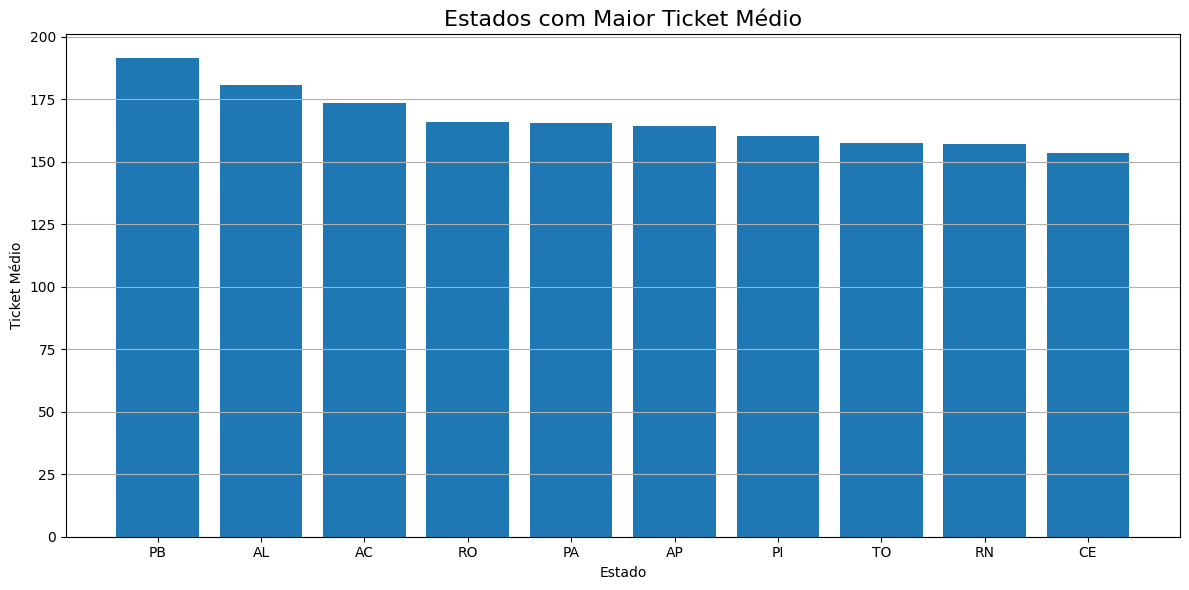

In [43]:
plt.figure(figsize=(12,6))

plt.bar(
    ticket_estado["customer_state"],
    ticket_estado["ticket_medio"]
)

plt.title(
    "Estados com Maior Ticket Médio",
    fontsize=16
)

plt.xlabel("Estado")

plt.ylabel("Ticket Médio")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig("../images/ticket_medio_estado.png", dpi=300, bbox_inches="tight")

plt.show()

#### Insight - Estados Com Maior Ticket Médio

Os estados com maior ticket médio apresentam consumidores com maior valor de compra por pedido, indicando regiões com maior poder de consumo e potencial para estratégias focadas em produtos de maior valor agregado.

Embora alguns estados apresentem ticket médio elevado, isso não significa necessariamente maior faturamento ou maior volume de vendas. Em muitos casos, estados com menor quantidade de pedidos podem ter a média aumentada por compras pontuais de maior valor, enquanto estados com grande volume de vendas tendem a possuir ticket médio mais equilibrado.

### Evolução do Faturamento ao Longo do Tempo

In [44]:
vendas_mes = vendas_mes.iloc[:-1]

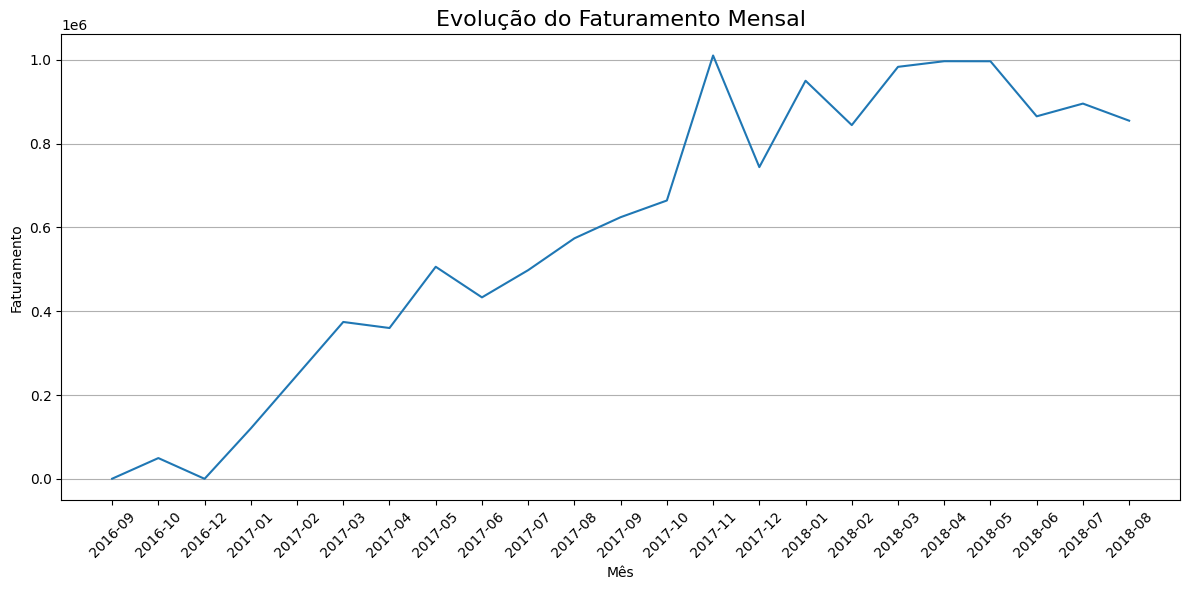

In [45]:
plt.figure(figsize=(12,6))

plt.plot(
    vendas_mes["mes"],
    vendas_mes["faturamento"]
)

plt.title(
    "Evolução do Faturamento Mensal",
    fontsize=16
)

plt.xlabel("Mês")

plt.ylabel("Faturamento")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.savefig("../images/faturamento_mensal.png", dpi=300, bbox_inches="tight")

plt.show()

#### Insight - Evolução do Faturamento Mensal

O faturamento apresenta crescimento ao longo do período analisado, indicando expansão das vendas e aumento da atividade comercial da plataforma. Além disso, alguns períodos apresentam oscilações que podem estar relacionadas a sazonalidades do mercado e datas comemorativas.

### Categorias com alto faturamento mas avaliação baixa

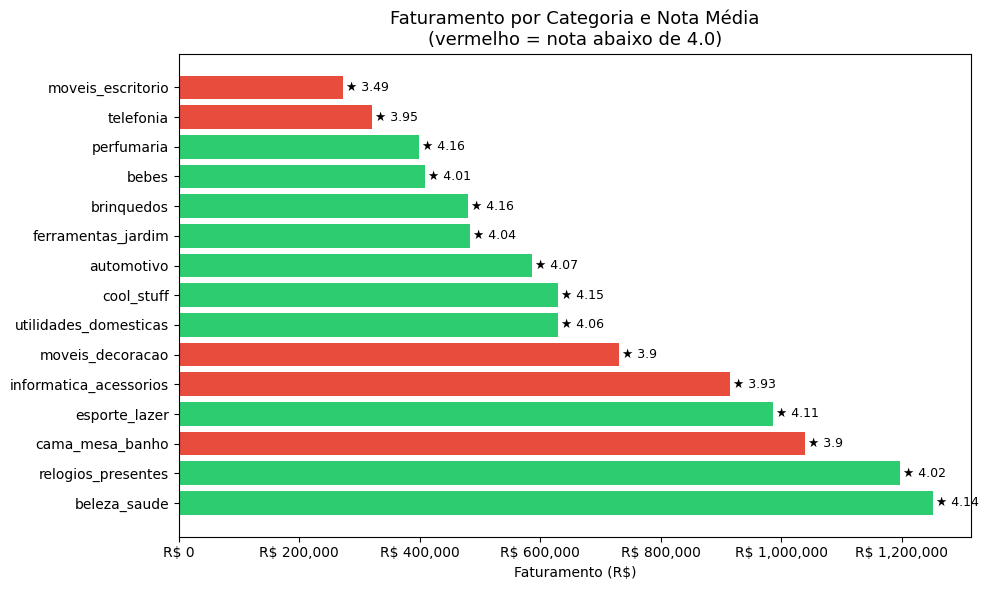

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

cores = ["#e74c3c" if nota < 4.0 else "#2ecc71" for nota in df_cat_review["nota_media"]]

bars = ax.barh(df_cat_review["categoria"], df_cat_review["faturamento"], color=cores)

ax.set_xlabel("Faturamento (R$)")
ax.set_title("Faturamento por Categoria e Nota Média\n(vermelho = nota abaixo de 4.0)", fontsize=13)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))

for i, (fat, nota) in enumerate(zip(df_cat_review["faturamento"], df_cat_review["nota_media"])):
    ax.text(fat + 5000, i, f"★ {nota}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../images/categorias_nota.png", dpi=300, bbox_inches="tight")
plt.show()

#### Insight — Categorias com alto faturamento e avaliação baixa

Algumas categorias com alto volume de vendas apresentam nota média abaixo de 4.0,
o que representa um risco para a retenção de clientes. Categorias em vermelho merecem
atenção prioritária da operação, pois combinam relevância financeira com insatisfação do consumidor.

### Pedidos por dia da semana e hora do dia

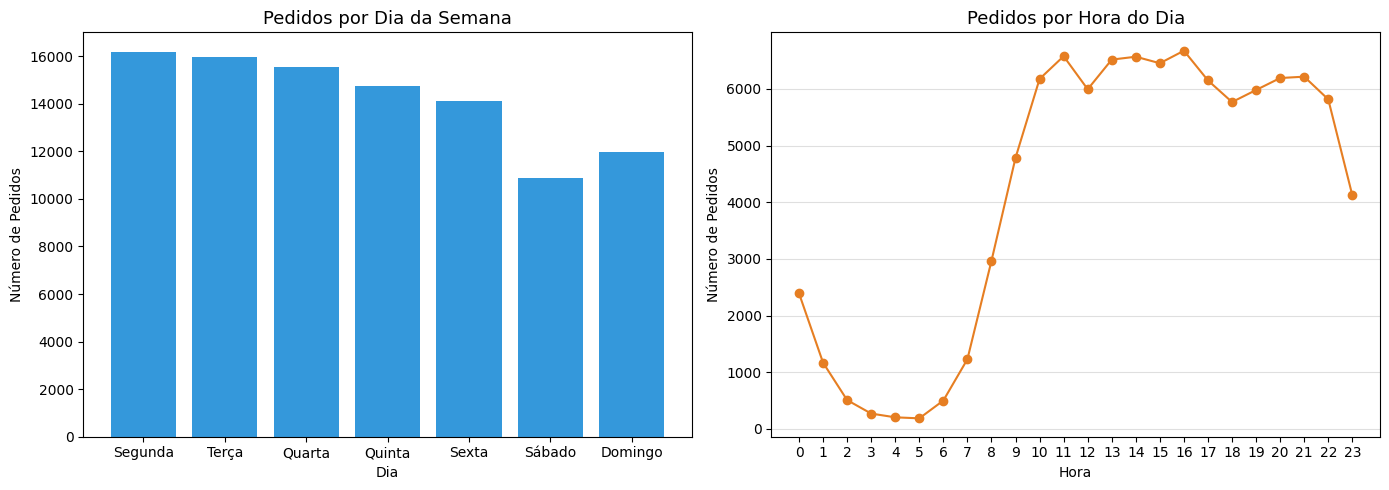

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — por dia da semana
ax1.bar(pedidos_dia.index, pedidos_dia.values, color="#3498db")
ax1.set_title("Pedidos por Dia da Semana", fontsize=13)
ax1.set_ylabel("Número de Pedidos")
ax1.set_xlabel("Dia")

# Gráfico 2 — por hora
ax2.plot(pedidos_hora.index, pedidos_hora.values, marker="o", color="#e67e22")
ax2.set_title("Pedidos por Hora do Dia", fontsize=13)
ax2.set_ylabel("Número de Pedidos")
ax2.set_xlabel("Hora")
ax2.set_xticks(range(0, 24))
ax2.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("../images/pedidos_tempo.png", dpi=300, bbox_inches="tight")
plt.show()

#### Insight — Comportamento Temporal dos Pedidos

Os pedidos se concentram nos dias úteis, com queda relevante no fim de semana.
Durante o dia, o pico de compras ocorre entre 10h e 16h, com destaque para o horário
do almoço — comportamento típico de consumidores comprando no intervalo do trabalho.
Esse padrão pode guiar estratégias de campanhas e envio de notificações.

### Frete vs distância (quem paga mais?)

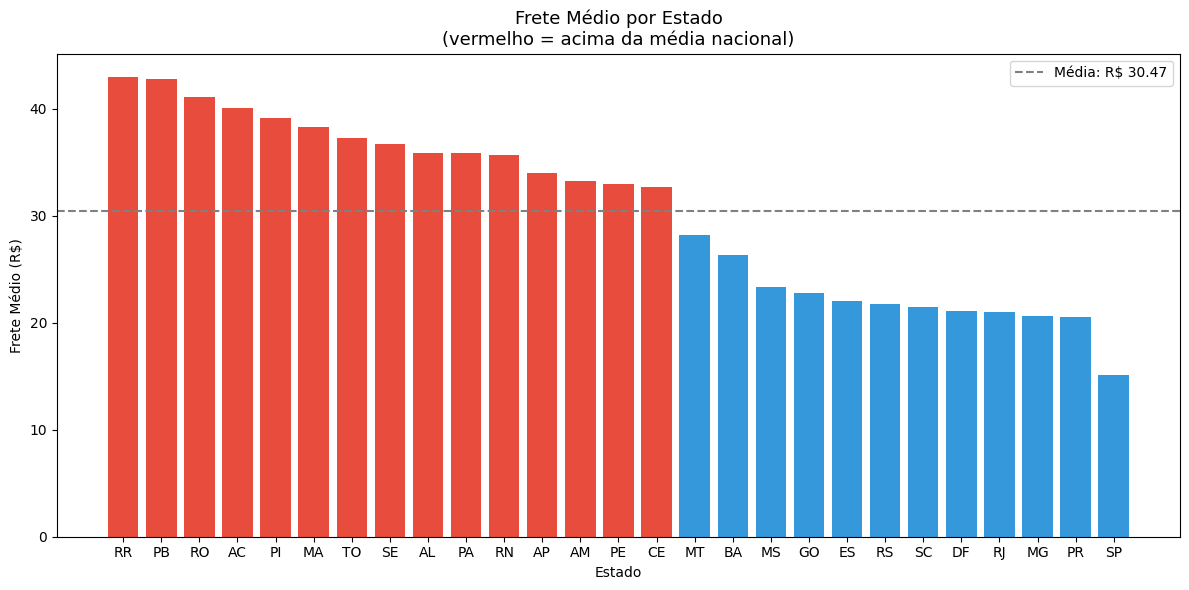

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))

cores_frete = ["#e74c3c" if f > 30 else "#3498db" for f in df_frete["frete_medio"]]

ax.bar(df_frete["estado"], df_frete["frete_medio"], color=cores_frete)
ax.axhline(y=df_frete["frete_medio"].mean(), color="gray", linestyle="--", label=f'Média: R$ {df_frete["frete_medio"].mean():.2f}')
ax.set_title("Frete Médio por Estado\n(vermelho = acima da média nacional)", fontsize=13)
ax.set_xlabel("Estado")
ax.set_ylabel("Frete Médio (R$)")
ax.legend()

plt.tight_layout()
plt.savefig("../images/frete_estado.png", dpi=300, bbox_inches="tight")
plt.show()

#### Insight — Frete Médio por Estado

Estados do Norte e Nordeste pagam fretes significativamente mais altos que SP e RJ,
o que explica o maior ticket médio observado nessas regiões — parte do valor gasto
é absorvida pelo frete, não pelo produto em si. Isso representa uma barreira de acesso
para consumidores mais distantes dos grandes centros logísticos.

## Conclusão

O projeto permitiu aplicar técnicas de análise de dados em um cenário real de e-commerce utilizando Python, SQL, Pandas e Matplotlib. Ao longo das análises, foi possível identificar padrões de vendas, categorias com maior relevância, diferenças regionais no comportamento de consumo e a evolução do faturamento ao longo do tempo.

As consultas SQL possibilitaram explorar os dados de forma estruturada, enquanto as visualizações gráficas facilitaram a interpretação dos resultados e a identificação de tendências importantes para o negócio.

Além disso, o projeto contribuiu para o desenvolvimento de habilidades fundamentais para a área de dados, como manipulação de dados, criação de consultas SQL, análise exploratória, visualização de informações e geração de insights de negócio.